<a href="https://colab.research.google.com/github/cailuj/TCC/blob/main/fase_1_resnet50_grid_search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#GridSearch com ResNet50

## Configuração e Carregamento de Dados do Drive

In [ ]:
import pandas as pd
import tensorflow as tf
import itertools
import os
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.backend import clear_session
from google.colab import drive
import itertools
import json

drive.mount('/content/drive')

Mounted at /content/drive


## Pipeline dos dados e One-Hot Encoding


In [ ]:
dataset_path = Path('/content/drive/MyDrive/organized data')

filepaths = []
labels = []

if dataset_path.exists():
    for filepath in dataset_path.glob('*/*'):
        if filepath.is_file():
            filepaths.append(str(filepath))
            labels.append(filepath.parent.name)

    df = pd.DataFrame({'filepath': filepaths, 'label': labels})
    print(f"Total images found: {len(df)}")

    if not df.empty:
        train_val_df, test_df = train_test_split(
            df,
            test_size=0.2,
            stratify=df['label'],
            random_state=42
        )

        train_df, val_df = train_test_split(
            train_val_df,
            test_size=0.2,
            stratify=train_val_df['label'],
            random_state=42
        )

        unique_labels = df['label'].unique()
        label_to_int = {label: i for i, label in enumerate(unique_labels)}

        train_df['label_encoded'] = train_df['label'].map(label_to_int)
        val_df['label_encoded'] = val_df['label'].map(label_to_int)
        test_df['label_encoded'] = test_df['label'].map(label_to_int)

        print(f"Training set size: {len(train_df)} ({len(train_df)/len(df):.1%})")
        print(f"Validation set size: {len(val_df)} ({len(val_df)/len(df):.1%})")
        print(f"Test set size: {len(test_df)} ({len(test_df)/len(df):.1%})")

        print(train_df.head())
    else:
        print("No images found in the specified directory.")
else:
    print(f"Directory not found: {dataset_path}")

Total images found: 7809
Training set size: 4997 (64.0%)
Validation set size: 1250 (16.0%)
Test set size: 1562 (20.0%)
                                               filepath   label  label_encoded
2079  /content/drive/MyDrive/organized data/benign/D...  benign              0
82    /content/drive/MyDrive/organized data/benign/A...  benign              0
5708  /content/drive/MyDrive/organized data/normal/A...  normal              2
176   /content/drive/MyDrive/organized data/benign/A...  benign              0
1961  /content/drive/MyDrive/organized data/benign/A...  benign              0


One-hot encoding se fez necessário pela quantidade de classes

Os dados foram divididos em 20% para teste, do restante 20% para validação e 80% para treino.

In [ ]:
def process_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = tf.keras.applications.resnet50.preprocess_input(img)
    label = tf.one_hot(label, depth=3)
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices((train_df['filepath'].values, train_df['label_encoded'].values))
val_ds = tf.data.Dataset.from_tensor_slices((val_df['filepath'].values, val_df['label_encoded'].values))
test_ds = tf.data.Dataset.from_tensor_slices((test_df['filepath'].values, test_df['label_encoded'].values))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(process_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(process_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(process_image, num_parallel_calls=AUTOTUNE)

BATCH_SIZE = 32
SHUFFLE_BUFFER = 1000

train_ds = train_ds.shuffle(SHUFFLE_BUFFER).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print(train_ds.element_spec)

(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))


##Grid Search


In [ ]:
activations = ['relu', 'swish']
learning_rates = [1e-3, 1e-4]
optimizers = ['Adam', 'SGD']

history_storage = {}
combinations = list(itertools.product(activations, learning_rates, optimizers))
print(f"\nTotal combinations to test: {len(combinations)}")

for i, (act, lr, opt_name) in enumerate(combinations):
    clear_session()

    model_name = f"{act}_{lr}_{opt_name}"
    print(f"\nTraining model {i+1}/{len(combinations)}: {model_name}")

    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    inputs = Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation=act)(x)
    outputs = Dense(3, activation='softmax')(x)
    model = Model(inputs, outputs)

    if opt_name == 'Adam':
        optimizer = Adam(learning_rate=lr)
    else:
        optimizer = SGD(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')]
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=50,
        verbose=1
    )

    history_storage[model_name] = history.history
    final_val_recall = history.history['val_recall'][-1]
    print(f"Finished {model_name} - Final Val Recall: {final_val_recall:.4f}")


Total combinations to test: 8

Training model 1/8: relu_0.001_Adam
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 270s 1s/step - accuracy: 0.5339 - loss: 1.1685 - precision: 0.5701 - recall: 0.4674 - val_accuracy: 0.6504 - val_loss: 0.7076 - val_precision: 0.7128 - val_recall: 0.5600
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 119ms/step - accuracy: 0.6625 - loss: 0.6944 - precision: 0.7250 - recall: 0.5686 - val_accuracy: 0.6704 - val_loss: 0.6730 - val_precision: 0.7367 - val_recall: 0.5864
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 120ms/step - accuracy: 0.6872 - loss: 0.6454 - precision: 0.7344 - recall: 0.6240 - val_accuracy: 0.6976 - val_loss: 0.6472 - val_precision: 0.7537 - val_recall: 0.6120
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 117ms/step - accuracy: 0.7290 - loss: 0.5877 - precision: 0.7785 - recall: 0.6663 - val_accuracy: 0.6848 - val_loss: 0.6414 - val_precision: 0.7402 - val_recall: 0.6200
Epoch 5/50
157/157 ━━━━━━━━━━━━

## Visualizando as performances


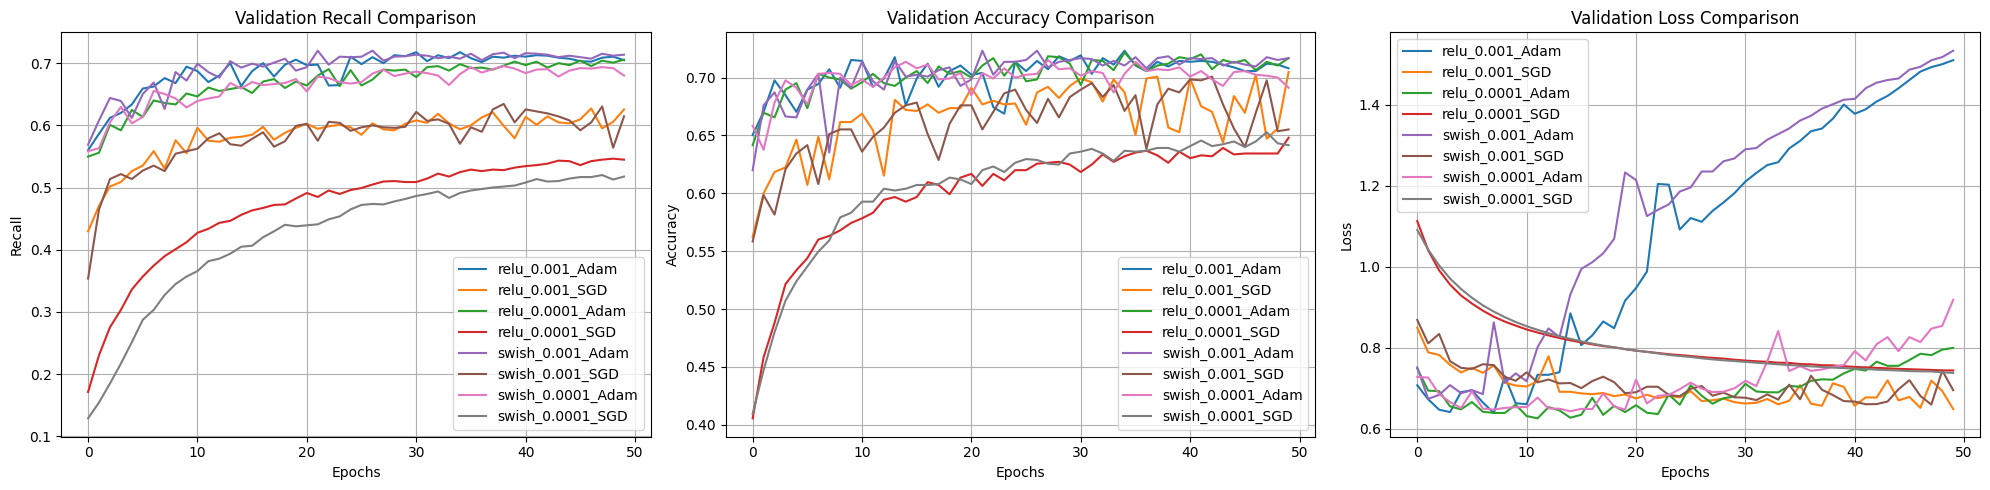

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for model_name, history in history_storage.items():
    val_recall_key = next((k for k in history.keys() if k.startswith('val_recall')), None)
    if val_recall_key:
        axes[0].plot(history[val_recall_key], label=model_name)

    if 'val_accuracy' in history:
        axes[1].plot(history['val_accuracy'], label=model_name)

    if 'val_loss' in history:
        axes[2].plot(history['val_loss'], label=model_name)

axes[0].set_title('Validation Recall Comparison')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Recall')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Validation Accuracy Comparison')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

axes[2].set_title('Validation Loss Comparison')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## Selecionando melhor modelo

In [ ]:
best_model_name = ""
best_val_recall = -1.0

for model_name, history in history_storage.items():
    val_recall_key = next((k for k in history.keys() if k.startswith('val_recall')), None)

    if val_recall_key:
        max_val_recall = max(history[val_recall_key])
        if max_val_recall > best_val_recall:
            best_val_recall = max_val_recall
            best_model_name = model_name

print(f"Best Model Selected: {best_model_name} with Val Recall: {best_val_recall:.4f}")

best_act, best_lr_str, best_opt_name = best_model_name.split('_')
best_lr = float(best_lr_str)

print(f"Retraining with: Activation={best_act}, LR={best_lr}, Optimizer={best_opt_name}")

tf.keras.backend.clear_session()

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation=best_act)(x)
outputs = Dense(3, activation='softmax')(x)
final_model = Model(inputs, outputs)

if best_opt_name == 'Adam':
    optimizer = Adam(learning_rate=best_lr)
else:
    optimizer = SGD(learning_rate=best_lr)

final_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')]
)

final_history = final_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    verbose=1
)


Best Model Selected: swish_0.001_Adam with Val Recall: 0.7200
Retraining with: Activation=swish, LR=0.001, Optimizer=Adam
Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 42s 181ms/step - accuracy: 0.5552 - loss: 1.1987 - precision: 0.5851 - recall: 0.4830 - val_accuracy: 0.6400 - val_loss: 0.7461 - val_precision: 0.6724 - val_recall: 0.5912
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 117ms/step - accuracy: 0.6627 - loss: 0.6937 - precision: 0.7120 - recall: 0.5852 - val_accuracy: 0.6488 - val_loss: 0.7037 - val_precision: 0.7057 - val_recall: 0.5888
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 118ms/step - accuracy: 0.6965 - loss: 0.6276 - precision: 0.7565 - recall: 0.6313 - val_accuracy: 0.6360 - val_loss: 0.7220 - val_precision: 0.6802 - val_recall: 0.5768
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 119ms/step - accuracy: 0.7246 - loss: 0.5888 - precision: 0.7706 - recall: 0.6669 - val_accuracy: 0.6792 - val_loss: 0.6720 - val_precision: 0.7431 - val_recall: 0.5832
Epoch 5/50
157/157 ━━━━━━━

## Métricas gerais


In [ ]:
test_ds = tf.data.Dataset.from_tensor_slices((test_df['filepath'].values, test_df['label_encoded'].values))
test_ds = test_ds.map(process_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("Evaluating on Test Set...")
test_loss, test_acc, test_recall, test_precision = final_model.evaluate(test_ds)

epsilon = 1e-7
test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall + epsilon)

print(f"\nTest Metrics:")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"F1-Score: {test_f1:.4f}")

model_save_path = '/content/drive/MyDrive/best_resnet50.keras'
final_model.save(model_save_path)
print(f"\nModel saved to {model_save_path}")

results = {
    'test_loss': test_loss,
    'test_accuracy': test_acc,
    'test_recall': test_recall,
    'test_precision': test_precision,
    'test_f1_score': test_f1
}

results_path = '/content/drive/MyDrive/resnet50_results.json'
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

print(f"Results saved to {results_path}")

Evaluating on Test Set...
49/49 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.7391 - loss: 1.2770 - precision: 0.7400 - recall: 0.7388

Test Metrics:
Loss: 1.2843
Accuracy: 0.7350
Recall: 0.7337
Precision: 0.7365
F1-Score: 0.7351

Model saved to /content/drive/MyDrive/best_resnet50.keras
Results saved to /content/drive/MyDrive/resnet50_results.json


In [ ]:
print("ANÁLISE DOS RESULTADOS DO GRID SEARCH\n")

if 'history_storage' in locals() and history_storage:
    for model_name, history in history_storage.items():
        val_recall_key = next((k for k in history.keys() if k.startswith('val_recall')), None)

        if val_recall_key:
            max_val_recall = max(history[val_recall_key])
            print(f"Modelo {model_name}: Recall Máx. Validação = {max_val_recall:.4f}")
        else:
            print(f"Modelo {model_name}: Recall de validação não encontrado.")
else:
    print("Nenhum histórico de treinamento encontrado na variável 'history_storage'. Certifique-se de ter executado o Grid Search.")

ANÁLISE DOS RESULTADOS DO GRID SEARCH

Modelo relu_0.001_Adam: Recall Máx. Validação = 0.7176
Modelo relu_0.001_SGD: Recall Máx. Validação = 0.6272
Modelo relu_0.0001_Adam: Recall Máx. Validação = 0.7056
Modelo relu_0.0001_SGD: Recall Máx. Validação = 0.5464
Modelo swish_0.001_Adam: Recall Máx. Validação = 0.7200
Modelo swish_0.001_SGD: Recall Máx. Validação = 0.6344
Modelo swish_0.0001_Adam: Recall Máx. Validação = 0.6952
Modelo swish_0.0001_SGD: Recall Máx. Validação = 0.5200
